[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


train samples : 36000
val samples : 24000
test samples : 40000


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBartModel.

All the weights of TFBartModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBartModel for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 64)]                 0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 64)]                 0         []                            
 )                                                                                                
                                                                                                  
 tf_bart_model (TFBartModel  TFSeq2SeqModelOutput(last_   1394204   ['input_ids[0][0]',           
 )                           hidden_state=(None, 64, 76   16         'attention_mask[0][0]']      
                             8),                                                              

/usr/local/lib/python3.10/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


563/563 [==============================] - 340s 559ms/step - loss: 1.5119 - acc: 0.3570 - val_loss: 1.0469 - val_acc: 0.6405
Epoch 2/10
563/563 [==============================] - 319s 567ms/step - loss: 1.1222 - acc: 0.5210 - val_loss: 0.8514 - val_acc: 0.7171
Epoch 3/10
563/563 [==============================] - 307s 546ms/step - loss: 0.9793 - acc: 0.6097 - val_loss: 0.7211 - val_acc: 0.7450
Epoch 4/10
563/563 [==============================] - 307s 545ms/step - loss: 0.8757 - acc: 0.6577 - val_loss: 0.6323 - val_acc: 0.7760
Epoch 5/10
563/563 [==============================] - 307s 545ms/step - loss: 0.8040 - acc: 0.6945 - val_loss: 0.5523 - val_acc: 0.8091
Epoch 6/10
563/563 [==============================] - 308s 548ms/step - loss: 0.7477 - acc: 0.7147 - val_loss: 0.5294 - val_acc: 0.8092
Epoch 7/10
563/563 [==============================] - 312s 554ms/step - loss: 0.7073 - acc: 0.7383 - val_loss: 0.4984 - val_acc: 0.8248
Epoch 8/10
563/563 [==============================] - 307s 

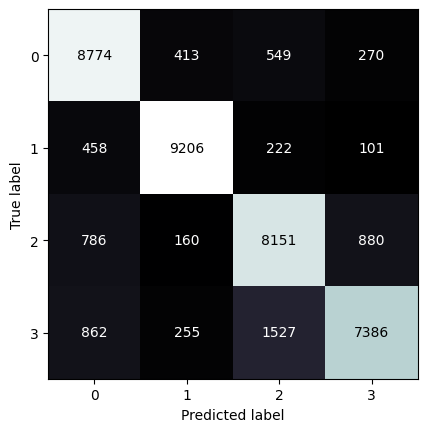

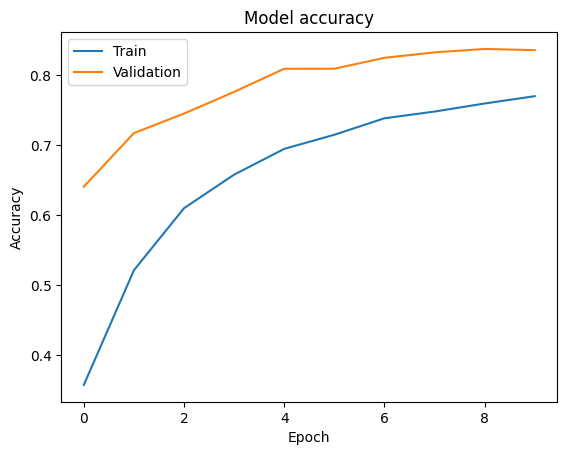

ValueError: multiclass format is not supported

In [ ]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from transformers import AutoTokenizer, TFBartModel
import numpy as np
import nltk
from sklearn.metrics import mean_squared_error, f1_score, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Load and prepare the data
data = pd.read_csv('/content/drive/MyDrive/news_topic/training_data.csv')
data.drop_duplicates(subset=['text'], inplace=True)
data = data.sample(frac=1, random_state=500).reset_index(drop=True)
data = data[:100000]

# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Text preprocessing functions
def text_preprocessing(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W", " ", text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

def drop_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

def delete_one_characters(text):
    return ' '.join([word if len(word) > 1 else "" for word in text.split()])

# Apply preprocessing
data['preprocessed_text'] = data['text'].apply(text_preprocessing).apply(drop_stopwords).apply(delete_one_characters)

# Encode labels
le = LabelEncoder()
data['encoded_label'] = le.fit_transform(data['label'].tolist())

# Train-validation-test split
train_val_data, test_data = train_test_split(data, test_size=0.4, random_state=500, stratify=data['encoded_label'])
train_data, val_data = train_test_split(train_val_data, test_size=0.4, random_state=500, stratify=train_val_data['encoded_label'])

print('train samples :', train_data.shape[0])
print('val samples :', val_data.shape[0])
print('test samples :', test_data.shape[0])

# Tokenization
checkpoint = "facebook/bart-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
MAX_LEN = 64

def tokenize(data):
    return tokenizer(text=data['preprocessed_text'].tolist(), add_special_tokens=True, max_length=MAX_LEN, truncation=True, padding=True, return_tensors='np', return_token_type_ids=False, return_attention_mask=True, verbose=True)

X_train = tokenize(train_data)
X_valid = tokenize(val_data)
X_test = tokenize(test_data)

# Create TensorFlow datasets
BATCH_SIZE = 64
AUTO = tf.data.AUTOTUNE

def parsing(text, label):
    input_ids = text['input_ids']
    attention_mask = text['attention_mask']
    return {'input_ids': input_ids, 'attention_mask': attention_mask}, label

train_loader = tf.data.Dataset.from_tensor_slices((X_train, train_data['encoded_label']))
train_dataset = train_loader.map(parsing, num_parallel_calls=AUTO).shuffle(BATCH_SIZE * 20).batch(BATCH_SIZE).prefetch(AUTO)

valid_loader = tf.data.Dataset.from_tensor_slices((X_valid, val_data['encoded_label']))
valid_dataset = valid_loader.map(parsing, num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)

test_loader = tf.data.Dataset.from_tensor_slices((X_test, test_data['encoded_label']))
test_dataset = test_loader.map(parsing, num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)

# Model building
input_ids = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
input_mask = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")
bart = TFBartModel.from_pretrained(checkpoint)

embeddings = bart(input_ids, attention_mask=input_mask).last_hidden_state
X = tf.keras.layers.GlobalMaxPool1D()(embeddings)
X = tf.keras.layers.Dense(256, activation='gelu')(X)
X = tf.keras.layers.Dropout(0.3)(X)
X = tf.keras.layers.Dense(128, activation='gelu')(X)
X = tf.keras.layers.Dropout(0.2)(X)
out = tf.keras.layers.Dense(4, activation='softmax')(X)

model = tf.keras.Model(inputs=[input_ids, input_mask], outputs=out)

# Fine-tuning BART
model.layers[2].trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['acc'])
model.summary()

# Training the model
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=2, min_delta=0.001, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/working/model.best.weights.h5', save_best_only=True, save_weights_only=True)
]

hist = model.fit(train_dataset, validation_data=valid_dataset, epochs=10, callbacks=my_callbacks)

# Test predictions
pred = model.predict(test_dataset)
test_pred = np.argmax(pred, axis=1)
y_test = test_data['encoded_label'].values

# Plot prediction results
def plot_prediction_results(y_true, y_pred, target_names=None):
    mse = mean_squared_error(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    clf = classification_report(y_true, y_pred, target_names=target_names if target_names else [str(i) for i in np.unique(y_true)])

    print(f'Mean Squared Error: {mse:.5f}')
    print(f'Weighted F1 Score: {f1:.3f}')
    print(f'Accuracy Score: {acc*100:.3f} %')
    print('\nClassification Report:\n', clf)
    print('\nConfusion Matrix:\n')
    cmd = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=target_names if target_names else np.unique(y_true),
        values_format='2g', cmap='bone', colorbar=False
    )
    plt.show()

plot_prediction_results(y_test, test_pred)

